## 📊 Análisis de Ventas en el rubro Farmacéutico 
### Proyecto Final – Data Science

Autor/a: Rubis Becerra

### Pregunta Problema

¿Qué variables explican de manera significativa el comportamiento de las ventas (sales) y cómo pueden utilizarse para construir un modelo predictivo confiable?

### Preguntas e Hipótesis de Interés

- ¿Cuál es la distribución de valores en ventas (sales) y su impacto?
- ¿Cómo se distribuyen los niveles de ventas?, ¿Cúal es el nivel de ventas predominante según el monto acumulado?
- ¿Cómo influye la región en la cantidad y magnitud de transacciones?
- ¿Cuál es la relación entre ventas con la cantidad y el precio?

Hipótesis iniciales:
- Es importante conocer la distribución de los valores de ventas ya que puede definir las estructuras del modelo predictivo.
- La mayoría de las transacciones se concentran en niveles bajos de ventas, lo que indica una posible dependencia del negocio en operaciones de menor ticket.
- Las ventas presentan diferencias significativas según variables claves del negocio (por ejemplo la región).
- Existe una relación positiva entre las ventas, cantidad y precio, lo que sugiere que estas variables son fuertes candidatas para el modelo predictivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/pharma_rsnx_processed.csv")

In [3]:
df.head(3)

,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team,Sales_Level
0,Prohaska-Kuhic,"Wunsch, Mills and Walter",Kielce,Poland,50.8725,20.6319,Pharmacy,Institution,Tacrodomide,Antipiretics,10.0,420,4200.0,January,2018,Stella Given,Alisha Cordwell,Charlie,Low
1,Cassin,Block-Romaguera Pharmaceutical Limited,Tarnowskie Góry,Poland,50.4500,18.8667,Hospital,Private,Finanel,Antimalarial,20.0,206,4120.0,January,2018,Sheila Stones,Britanny Bold,Delta,Low
2,Smith Inc,Doyle-Tillman Pharmaceutical Ltd,Dęblin,Poland,51.5667,21.8614,Hospital,Private,Tacrodomide,Antipiretics,2.0,420,840.0,January,2018,Stella Given,Alisha Cordwell,Charlie,Low


In [4]:
df.shape

(5000, 19)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Distributor        5000 non-null   object 
 1   Customer Name      5000 non-null   object 
 2   City               5000 non-null   object 
 3   Country            5000 non-null   object 
 4   Latitude           5000 non-null   float64
 5   Longitude          5000 non-null   float64
 6   Channel            5000 non-null   object 
 7   Sub-channel        5000 non-null   object 
 8   Product Name       5000 non-null   object 
 9   Product Class      5000 non-null   object 
 10  Quantity           5000 non-null   float64
 11  Price              5000 non-null   int64  
 12  Sales              5000 non-null   float64
 13  Month              5000 non-null   object 
 14  Year               5000 non-null   int64  
 15  Name of Sales Rep  5000 non-null   object 
 16  Manager            5000 

In [6]:
df.isna().sum()

Distributor          0
Customer Name        0
City                 0
Country              0
Latitude             0
Longitude            0
Channel              0
Sub-channel          0
Product Name         0
Product Class        0
Quantity             0
Price                0
Sales                0
Month                0
Year                 0
Name of Sales Rep    0
Manager              0
Sales Team           0
Sales_Level          0
dtype: int64

### EDA

In [7]:
df.describe()

,Latitude,Longitude,Quantity,Price,Sales,Year
count,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000
mean,50.984883,10.839572,97.813667,414.762400,3.848547e+04,2018.395000
std,1.611324,4.169709,482.350403,225.105107,1.540812e+05,1.037299
min,47.514200,6.083800,-1800.000000,22.000000,-2.866420e+05,2017.000000
25%,49.891700,7.940800,6.000000,206.000000,1.881000e+03,2018.000000
50%,51.123600,9.397800,20.000000,445.000000,6.222000e+03,2018.000000
75%,52.091700,12.150800,50.000000,610.000000,1.901400e+04,2019.000000
max,54.781900,23.566700,20000.000000,794.000000,4.023000e+06,2020.000000


### Exploración de Valores negativos en la variable Sales:

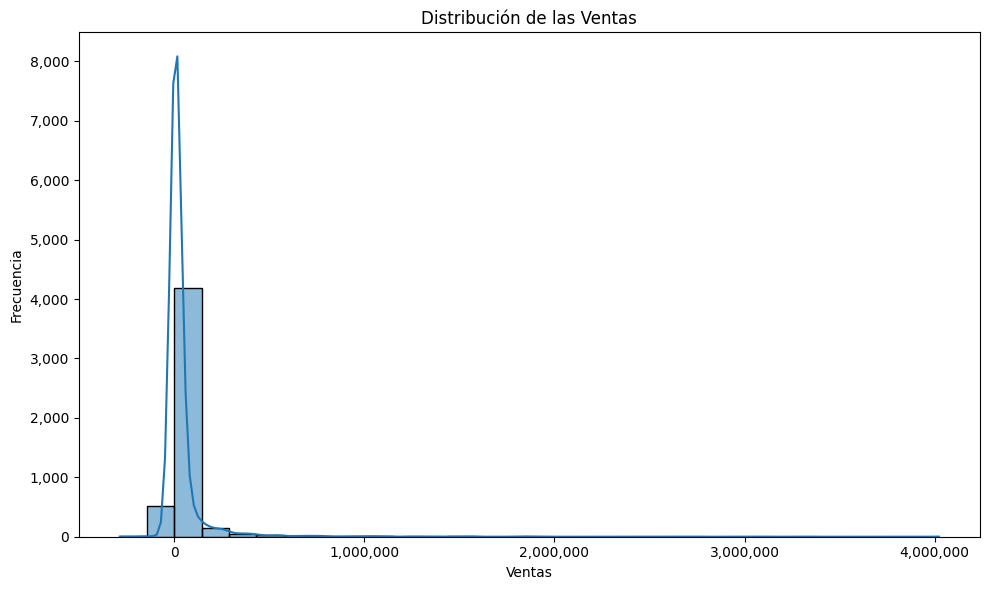

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Sales", bins=30, kde=True)
plt.title("Distribución de las Ventas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")

#Separador de miles en eje Y X
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

#### Comentarios Histograma "Distribución de Ventas"

Muestra una fuerte concentración de ventas en valores bajos y la presencia de algunos valores extremadamente altos, lo que genera una distribución asimétrica positiva. Esta situación dificulta la visualización de los valores intermedios y evidencia la existencia de outliers que influyen en las medidas de tendencia central. Un pequeño número de ventas concentra una parte significativa del volumen total.

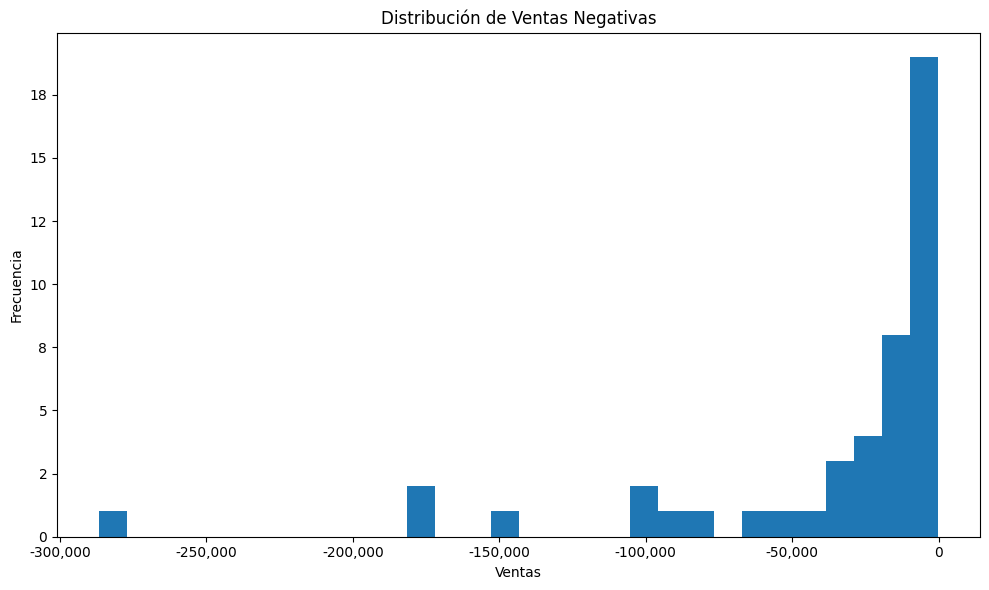

In [9]:
plt.figure(figsize=(10, 6))
ventas_negativas = df[df["Sales"] < 0]["Sales"]
plt.hist(ventas_negativas, bins=30)
plt.title("Distribución de Ventas Negativas")
plt.xlabel("Ventas")
plt.ylabel("Frecuencia")
ax = plt.gca()

#Separador de miles en eje X (montos negativos); Y (si la frecuencia fuera grande)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

In [10]:
#Con el describe se visualizan valores negativos en la variable Sales (existen ventas negativas), se busca conocer el porcentaje de la distribución
df["Sales"].lt(0).value_counts(normalize=True) * 100

Sales
False    99.1
True      0.9
Name: proportion, dtype: float64

#### Diagnóstico - Exploración de Valores negativos en la variable Sales:
¿Cuál es la distribución de valores en ventas (sales) y su impacto?

Los valores negativos en ventas representan menos del 1% del total, por lo que se consideran ruido operativo y no un fenómeno estructural relevante para un análisis predictivo independiente. El histograma de ventas negativas permite identificar su frecuencia y magnitud, sugiriendo que podrían estar asociados a notas de crédito, cancelaciones o ajustes administrativos.

### Gráfico de barras: Distribución del Nivel de Ventas y Monto Acumulado por Nivel

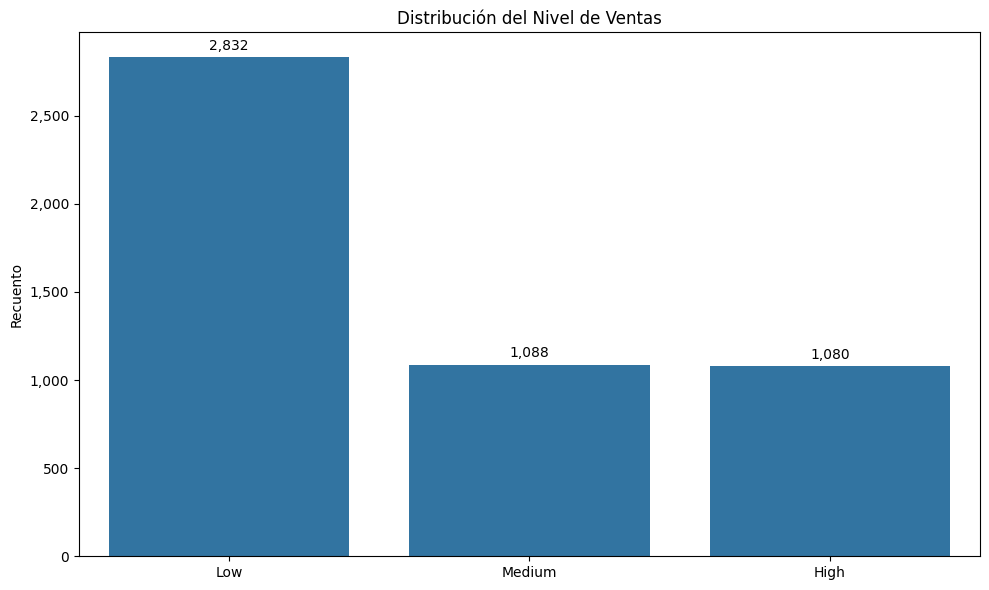

In [11]:
#Asegurar orden categórico
df["Sales_Level"] = pd.Categorical(df["Sales_Level"], categories=["Low", "Medium", "High"], ordered=True)

plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x="Sales_Level")
plt.title("Distribución del Nivel de Ventas")
plt.ylabel("Recuento")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

#Etiquetas con separador de miles
for container in ax.containers:
    ax.bar_label(container,labels=[f"{int(v):,}" for v in container.datavalues], padding=3)

#Eliminar el título del eje X
ax.set_xlabel("")

plt.tight_layout()
plt.show()

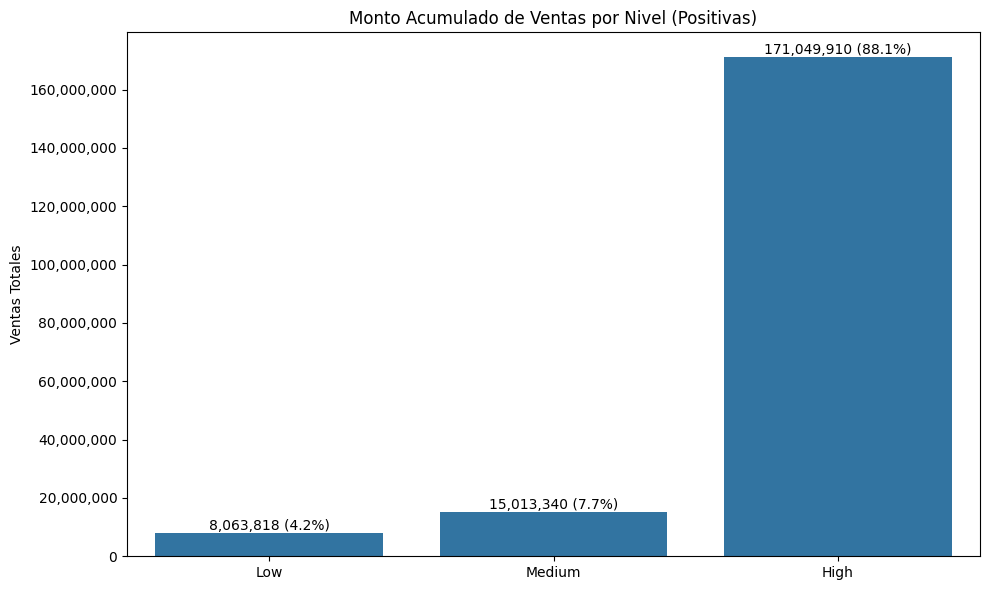

In [12]:
#Filtrar solo ventas positivas
df_positive = df[df["Sales"] > 0].copy()

#segurar orden categórico
df_positive["Sales_Level"] = pd.Categorical(df_positive["Sales_Level"], categories=["Low", "Medium", "High"], ordered=True)

#Calcular ventas acumuladas
ventas_por_nivel = (df_positive.groupby("Sales_Level", observed=False)["Sales"].sum().reset_index())

#Calcular porcentaje
total_ventas = ventas_por_nivel["Sales"].sum()
ventas_por_nivel["percentage"] = (ventas_por_nivel["Sales"] / total_ventas * 100)

#Graficar
plt.figure(figsize=(10,6))
ax = sns.barplot(data=ventas_por_nivel, x="Sales_Level", y="Sales")
plt.title("Monto Acumulado de Ventas por Nivel (Positivas)")
plt.ylabel("Ventas Totales")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

#Etiquetas con miles + porcentaje
for i, row in ventas_por_nivel.iterrows():
    ax.text(i, row["Sales"], f'{row["Sales"]:,.0f} ({row["percentage"]:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Diagnóstico - Distribución del Nivel de Ventas y Monto Acumulado por Nivel
¿Cómo se distribuyen los niveles de ventas?, ¿Cúal es el nivel de ventas predominante según el monto acumulado?

Aunque el nivel Low concentra la mayor cantidad de transacciones, el nivel High predomina ampliamente en términos de monto acumulado, representando el 88,1% de los ingresos totales. Esto indica que, si bien las ventas de menor ticket son más frecuentes, las ventas de alto valor son estratégicamente determinantes para el negocio.

El análisis se realizó considerando únicamente valores positivos, sin diferencias significativas respecto al total general.

### Gráfico de Barras y Boxplot: Promedio y Distribución de Ventas por País

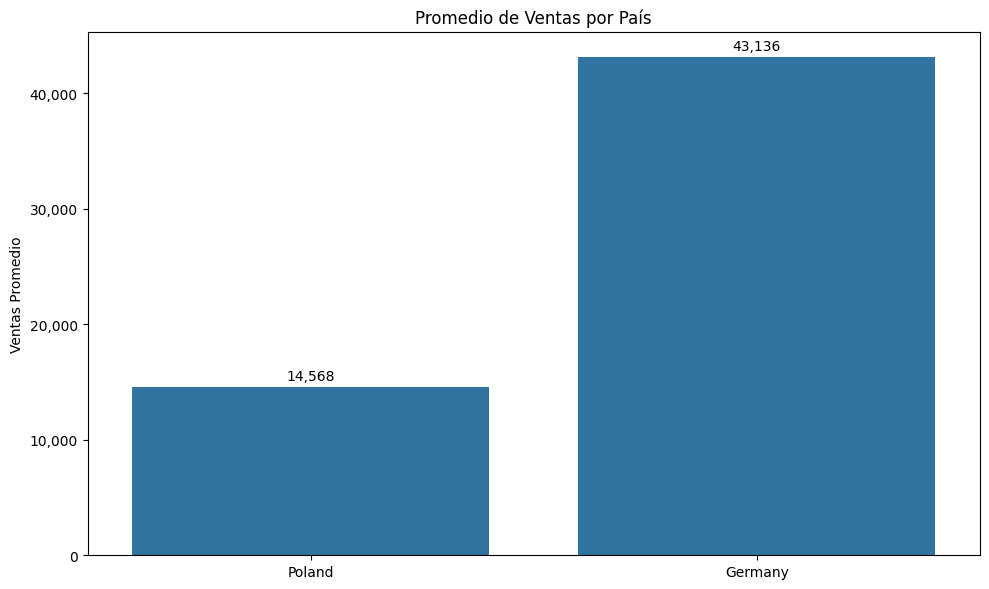

In [13]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df, x="Country", y="Sales", estimator="mean", errorbar=None)
plt.title("Promedio de Ventas por País")
plt.ylabel("Ventas Promedio")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

#Etiquetas encima de cada barra con separador de miles
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:,.0f}" for v in container.datavalues], padding=3)

plt.tight_layout()
plt.show()

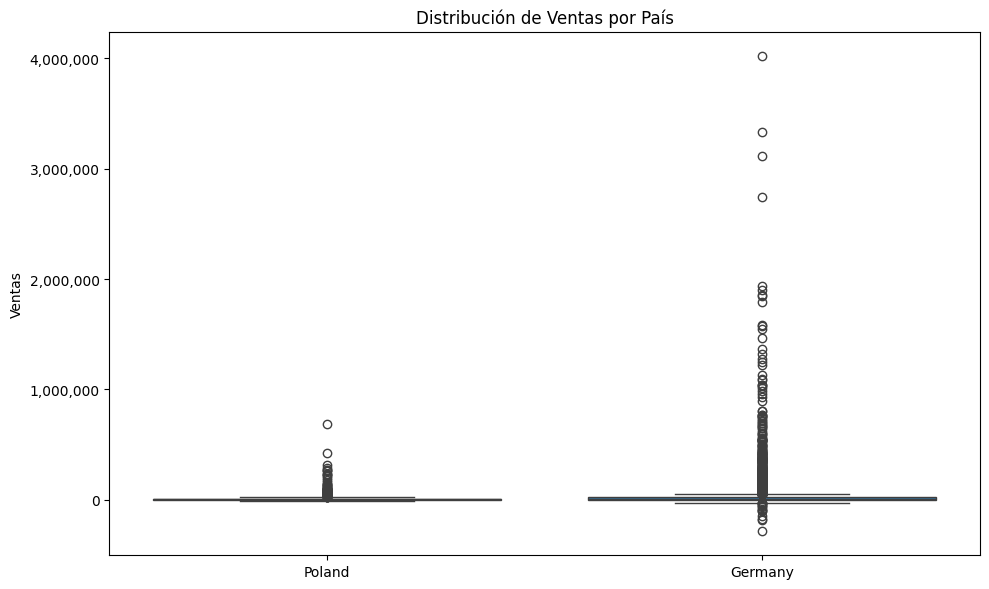

In [14]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=df, x="Country", y="Sales")
plt.title("Distribución de Ventas por País")
plt.ylabel("Ventas")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

#### Boxplot sin escala logarítmica:
Se presentó el boxplot en escala lineal con el objetivo de visualizar la dispersión completa de las ventas, incluyendo la presencia de outliers tanto positivos como negativos.

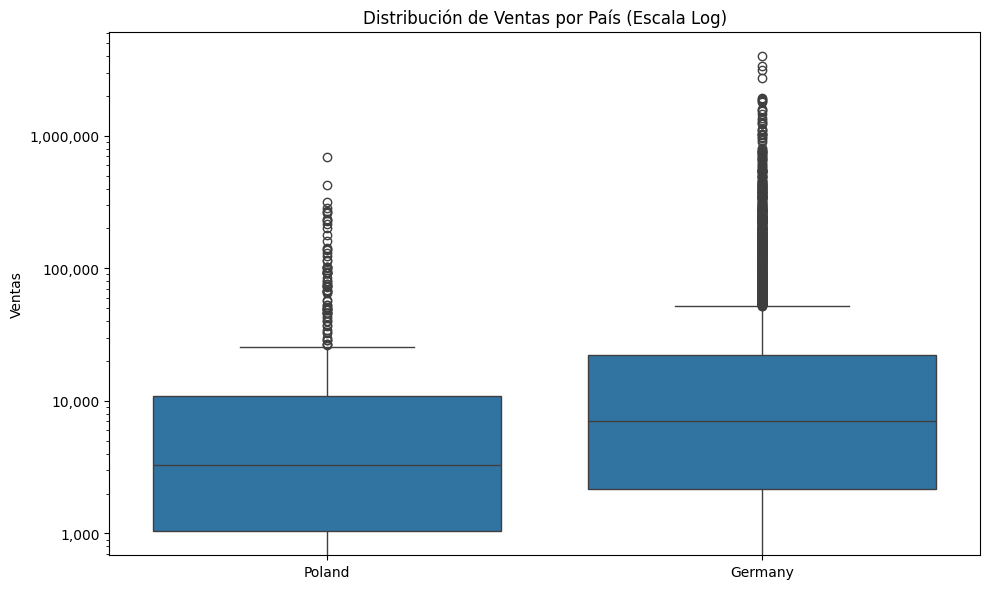

In [15]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=df, x="Country", y="Sales")
plt.title("Distribución de Ventas por País (Escala Log)")
plt.ylabel("Ventas")
ax.set_xlabel("")
  
#Aplicar escala log
plt.yscale("log")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

#### Diagnóstico - Promedio y Distribución de Ventas por País:
¿Cómo influye la región en la cantidad y magnitud de transacciones?

Se observa que Alemania concentra el mayor promedio de ventas, aproximadamente tres veces superior al de Polonia, lo que evidencia una mayor magnitud en sus transacciones. Además, es el país donde se registran tanto operaciones de alto valor como una mayor presencia de ventas negativas, sugiriendo mayor volumen y variabilidad operativa.   

### Diagrama de Dispersión y Matriz de Correlación - Relaciones entre Ventas vs Cantidad y Precio

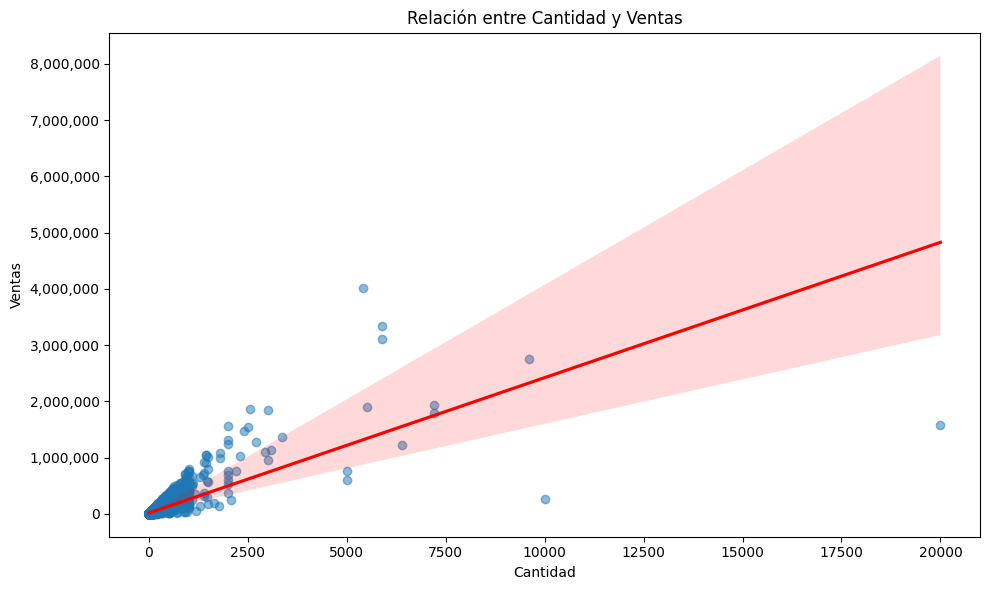

In [16]:
#Filtrar solo ventas positivas
df_positive = df[df["Sales"] > 0]

plt.figure(figsize=(10,6))
ax = sns.regplot(data=df_positive, x="Quantity", y="Sales", scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Relación entre Cantidad y Ventas")
plt.xlabel("Cantidad")
plt.ylabel("Ventas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

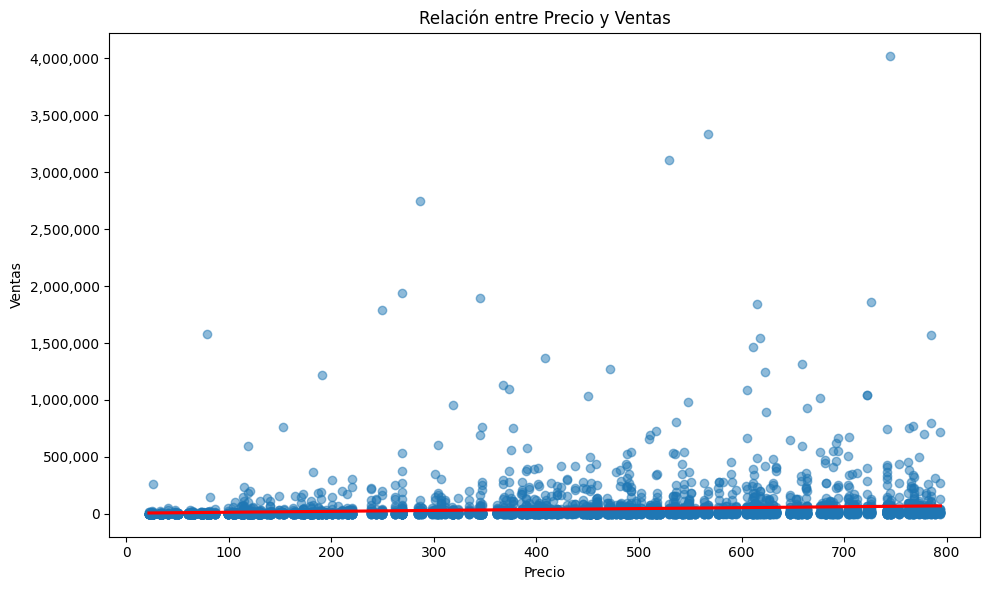

In [17]:
plt.figure(figsize=(10,6))
ax = sns.regplot(data=df_positive, x="Price", y="Sales", scatter_kws={"alpha":0.5}, line_kws={"color":"red"})
plt.title("Relación entre Precio y Ventas")
plt.xlabel("Precio")
plt.ylabel("Ventas")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

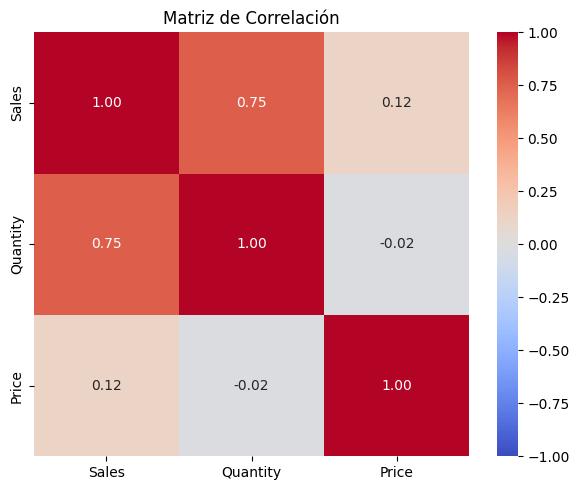

In [18]:
#Filtrar ventas positivas
df_positive = df[df["Sales"] > 0]

#Seleccionar variables numéricas relevantes
corr_matrix = df_positive[["Sales", "Quantity", "Price"]].corr()
corr_matrix

plt.figure(figsize=(6,5))
ax = sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

#### Diagnóstico - Relaciones entre Ventas vs Cantidad y Precio
¿Cuál es la relación entre ventas con la cantidad y el precio?

Se identifica una fuerte correlación positiva entre Sales y Quantity (r = 0.75), evidenciando que el volumen de unidades vendidas es un factor clave en la generación de ingresos. En contraste, la relación entre Sales y Price es débil (r = 0.12), lo que indica que el precio, de forma aislada, no explica significativamente la variación en las ventas. En este contexto, el volumen se posiciona como el principal impulsor del ingreso.